In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [19]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=1000, normalize=True):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.normalize = normalize
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.theta = None
        self.sse_history = []

    def fit(self, x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        if x.ndim == 1:
            x = x.reshape(-1, 1)
        if x.ndim != 2:
            raise ValueError("x must be a 1D or 2D array")

        self.x_mean = np.mean(x, axis=0)
        self.x_std = np.std(x, axis=0)
        self.x_std = np.where(self.x_std == 0, 1.0, self.x_std)

        if self.normalize:
            x_train = (x - self.x_mean) / self.x_std
        else:
            x_train = x

        n_samples, n_features = x_train.shape
        theta = np.zeros(n_features)
        theta_0 = 0.0
        self.sse_history = []

        for _ in range(self.n_iters):
            predictions = theta_0 + x_train @ theta
            errors = predictions - y

            gradient_0 = (2 / n_samples) * np.sum(errors)
            gradient = (2 / n_samples) * (x_train.T @ errors)

            theta_0 -= self.learning_rate * gradient_0
            theta -= self.learning_rate * gradient
            self.sse_history.append(np.sum(errors ** 2))

        if self.normalize:
            self.theta = theta / self.x_std
            self.theta_0 = theta_0 - np.sum(self.theta * self.x_mean)
        else:
            self.theta = theta
            self.theta_0 = theta_0

        self.theta_1 = self.theta[0]
        return self

    def predict(self, x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:
            if len(self.theta) == 1:
                x = x.reshape(-1, 1)
            else:
                x = x.reshape(1, -1)
        return self.theta_0 + x @ self.theta

    def mse(self, x, y):
        errors = np.asarray(y, dtype=float) - self.predict(x)
        return np.mean(errors ** 2)

    def plot_training(self, x, y):
        predictions = self.predict(x)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(self.sse_history)
        axes[0].set_title("SSE over iterations")
        axes[0].set_xlabel("Iteration")
        axes[0].set_ylabel("SSE")
        axes[0].grid(True)

        axes[1].scatter(np.asarray(x).ravel(), y, color="blue", label="Data points")
        axes[1].plot(np.asarray(x).ravel(), predictions, color="red", label="Regression line")
        axes[1].set_title("Regression line")
        axes[1].set_xlabel("House size (m²)")
        axes[1].set_ylabel("Price (thousands)")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()


linear = LinearRegressionGD(learning_rate=0.001, n_iters=100)
linear.fit(x, y)

print("theta_0 (intercept):", linear.theta_0)
print("theta_1 (slope):", linear.theta_1)

theta_0 (intercept): -1.4210854715202004e-14
theta_1 (slope): 0.5442995859347167


Predicted price for 70 m²: 38.100971015430154
MSE of the required model: 30755.369070566067


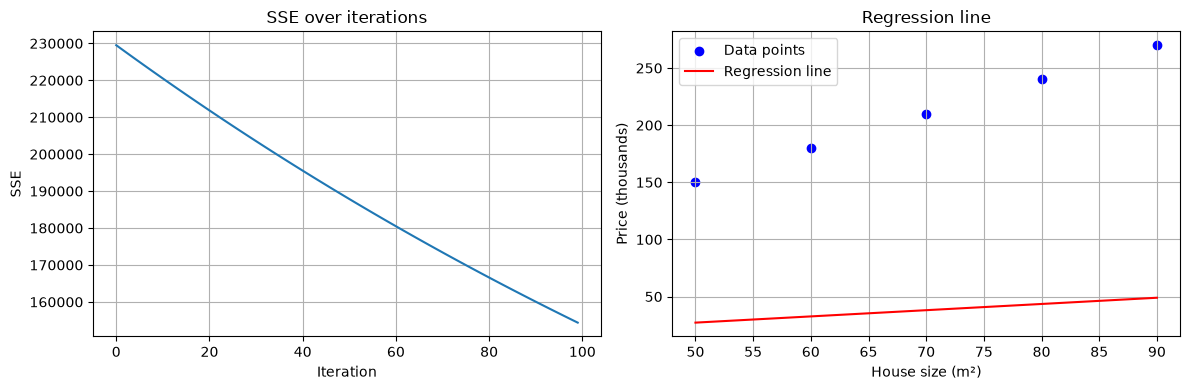

Final SSE with large learning rate: 1.487990821366718e-14
Final SSE with small learning rate: 228592.96803825535


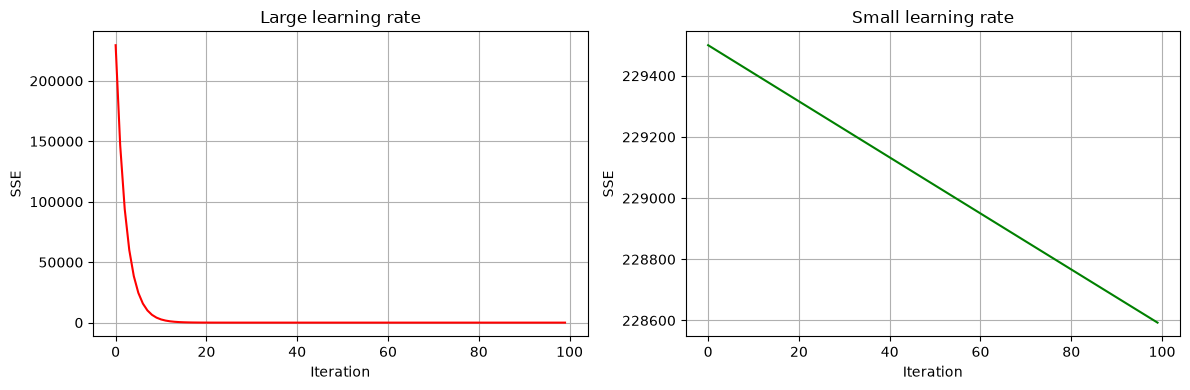

Normalized model MSE: 1.9046294324289615e-15
Unnormalized model MSE: 8.712014832720324e-05
Multiple-feature coefficients: [ 2.99998502 20.00028318]
Multiple-feature intercept: 0.00025601031785527084
Multiple-feature prediction: 270.0000566362032


In [20]:
# Prediction for a house with size 70 m²
house_size = np.array([70])
predicted_price = linear.predict(house_size)
print("Predicted price for 70 m²:", predicted_price[0])
print("MSE of the required model:", linear.mse(x, y))

# Visualize SSE and the regression line
linear.plot_training(x, y)

# Experiment with different learning rates
large_lr_model = LinearRegressionGD(learning_rate=0.1, n_iters=100)
large_lr_model.fit(x, y)

small_lr_model = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
small_lr_model.fit(x, y)

print("Final SSE with large learning rate:", large_lr_model.sse_history[-1])
print("Final SSE with small learning rate:", small_lr_model.sse_history[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(large_lr_model.sse_history, color="red")
axes[0].set_title("Large learning rate")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("SSE")
axes[0].grid(True)

axes[1].plot(small_lr_model.sse_history, color="green")
axes[1].set_title("Small learning rate")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("SSE")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Bonus 1 and 2: MSE and normalized vs. unnormalized X
normalized_model = LinearRegressionGD(
    learning_rate=0.1,
    n_iters=100,
    normalize=True
)
normalized_model.fit(x, y)

unnormalized_model = LinearRegressionGD(
    learning_rate=0.00001,
    n_iters=100,
    normalize=False
)
unnormalized_model.fit(x, y)

print("Normalized model MSE:", normalized_model.mse(x, y))
print("Unnormalized model MSE:", unnormalized_model.mse(x, y))

# Bonus 3: multiple features (house size and number of rooms)
x_multi = np.array([
    [50, 2],
    [60, 2],
    [70, 3],
    [80, 3],
    [90, 4]
])
y_multi = np.array([190, 220, 270, 300, 350])

multi_model = LinearRegressionGD(
    learning_rate=0.1,
    n_iters=1000,
    normalize=True
)
multi_model.fit(x_multi, y_multi)

new_house = np.array([[70, 3]])
print("Multiple-feature coefficients:", multi_model.theta)
print("Multiple-feature intercept:", multi_model.theta_0)
print("Multiple-feature prediction:", multi_model.predict(new_house)[0])

## Written Answers

### Data

- `x` represents the house size in square meters.
- `y` represents the house price in thousands.

### Regression parameters

The regression equation is:

$$\hat{y} = \theta_0 + \theta_1 x$$

- `theta_0` is the intercept: the predicted price when the house size is zero.
- `theta_1` is the slope: the change in predicted price for each additional square meter.

### Prediction

The dataset follows the relationship `price = 3 * size`, so a house of `70 m²` should cost about `210` thousand. The prediction produced with `learning_rate=0.001` and only `100` iterations is not reasonable because the model has not converged yet.

### SSE and convergence

SSE decreases as gradient descent updates the parameters in a direction that reduces the prediction errors. Convergence means that the parameters and SSE become nearly stable, so additional iterations produce only very small improvements.

### Learning-rate experiment

- The large learning rate reaches a low SSE quickly in this normalized implementation.
- The small learning rate decreases SSE slowly and needs more iterations.
- If the learning rate is too large, the updates can overshoot the minimum, causing oscillation, divergence, or `NaN` values.

To obtain a prediction close to `210`, increase the number of iterations or use a better-tuned learning rate in an additional experiment. Keep the required `0.001` and `100` settings for the original task result.